# AI6124 Assignment 1: Iris Joint Histogram and Bayesian Probability Analysis
## Assigned Attribute: Petal Length (PL)

---

### Assignment Summary

This notebook performs a complete probability-distribution analysis of the **Petal Length (PL)** attribute from the Iris dataset (150 samples, 3 classes). The analysis includes:

1. Loading and validating data from the course-supplied file
2. Quantizing PL into exactly 10 equal-width bins
3. Constructing the class-conditional/joint histogram distribution
4. Computing class priors, conditional probabilities, and posterior probabilities
5. Verifying Bayes' formula for even-numbered bins
6. Preparing results for odd-numbered bins in a Word document

### Learning Objectives

- Understand empirical probability distributions from histograms
- Apply Bayes' theorem to compute posterior class probabilities
- Distinguish between $P(r_i|C)$ (likelihood) and $P(C|r_i)$ (posterior)
- Verify the consistency of probability axioms on real data

### Data Convention Note

This analysis uses the course-supplied file's own header and class mapping **exactly as provided**:
- Column order: `SW, SL, PW, PL, Flower Class`
- Class codes: `1.0` = Setosa, `2.0` = Virginica, `3.0` = Versicolor

These labels are used as-is from the source file, even if they differ from familiar canonical Iris dataset conventions (e.g., `sklearn.datasets.load_iris()`).

---
## 0. Install Required Packages (Colab)

Run this cell to install packages needed for this notebook on Google Colab.

In [1]:
!pip install -q python-docx striprtf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 22.0 MB/s eta 0:00:00


---
## 1. Imports and Configuration

In [2]:
import pathlib
import re
import io
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from docx import Document
from docx.shared import Inches, Pt, Cm, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.enum.section import WD_ORIENT

from striprtf.striprtf import rtf_to_text

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

OUTPUT_DIR = pathlib.Path('outputs/assignment1_pl')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("All imports successful.")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

All imports successful.
Output directory: /content/outputs/assignment1_pl


---
## 2. Upload and Load the Course Data File

The source file `iris data.doc` is an RTF document saved with a `.doc` extension.

**Upload the file when prompted below**, then we parse it using `striprtf`.

In [3]:
# Upload the iris data.doc file from your local machine
from google.colab import files

print("Please upload 'iris data.doc' (the course-supplied RTF file):")
uploaded = files.upload()

# Identify the uploaded file
uploaded_filename = list(uploaded.keys())[0]
DATA_PATH = pathlib.Path(uploaded_filename)
print(f"\nUploaded file: {uploaded_filename} ({len(uploaded[uploaded_filename])} bytes)")

Please upload 'iris data.doc' (the course-supplied RTF file):


Saving iris data.doc to iris data.doc

Uploaded file: iris data.doc (16010 bytes)


In [4]:
# Convert RTF to plain text using striprtf
with open(DATA_PATH, 'r', errors='ignore') as f:
    rtf_content = f.read()

raw_text = rtf_to_text(rtf_content)
print(f"Converted RTF to plain text using striprtf.")
print(f"Extracted {len(raw_text)} characters of text.")
print("\nFirst 5 lines:")
for line in raw_text.splitlines()[:5]:
    print(f"  {line}")

Converted RTF to plain text using striprtf.
Extracted 3234 characters of text.

First 5 lines:
  // Anderson Iris Data (kkAng)
  // (Input_Cols) (Rows)
  4 150 (4 features: SW – Sepal Width, SL – Sepal Length, PW – Petal Width, PL – Petal-Length,) 150 samples
  SW	SL	PW	PL	Flower Class (1.0 – Setosa, 2.0 – Virginica, 3.0 – Versicolor)
  5.1	3.5	1.4	0.2	1.0


In [5]:
# Parse lines with exactly 5 numeric values
rows = []
for line in raw_text.splitlines():
    # Split on whitespace or tabs
    parts = re.split(r'[\s\t]+', line.strip())
    if len(parts) == 5:
        try:
            values = [float(p) for p in parts]
            rows.append(values)
        except ValueError:
            continue

print(f"Parsed {len(rows)} data rows with 5 numeric values each.")

# Create DataFrame with course-specified column names
df = pd.DataFrame(rows, columns=["SW", "SL", "PW", "PL", "class_code"])

# Map class codes to course labels
CLASS_MAP = {1.0: "Setosa", 2.0: "Virginica", 3.0: "Versicolor"}
df["class_name"] = df["class_code"].map(CLASS_MAP)

print(f"DataFrame created with shape: {df.shape}")

Parsed 150 data rows with 5 numeric values each.
DataFrame created with shape: (150, 6)


In [6]:
# Validation assertions
assert len(df) == 150, f"Expected 150 rows, got {len(df)}"
assert df[["SW", "SL", "PW", "PL"]].shape[1] == 4, "Expected 4 numeric feature columns"
assert df[["SW", "SL", "PW", "PL", "class_code"]].isnull().sum().sum() == 0, "Missing values found"
assert set(df["class_code"].unique()) == {1.0, 2.0, 3.0}, f"Unexpected class codes: {df['class_code'].unique()}"
assert all(df["class_code"].value_counts() == 50), "Each class must have exactly 50 samples"
assert pd.api.types.is_numeric_dtype(df["PL"]), "PL must be numeric"

print("=" * 60)
print("ALL VALIDATION ASSERTIONS PASSED")
print("=" * 60)
print(f"\nValidated sample size: 150. No resampling performed.")
print(f"Assigned attribute: PL, taken from the fourth numeric column of the course file.")

ALL VALIDATION ASSERTIONS PASSED

Validated sample size: 150. No resampling performed.
Assigned attribute: PL, taken from the fourth numeric column of the course file.


In [7]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print(f"\nDataFrame shape: {df.shape}")
print(f"\nData types:")
print(df.dtypes)

print(f"\nMissing value counts:")
print(df.isnull().sum())

print(f"\nClass counts (by code):")
print(df["class_code"].value_counts().sort_index())

print(f"\nClass counts (by name):")
print(df["class_name"].value_counts())

print(f"\nDescriptive statistics for PL:")
pl_stats = df["PL"].describe()
pl_stats["median"] = df["PL"].median()
pl_stats["std"] = df["PL"].std()
print(pl_stats)

First 5 rows:


,SW,SL,PW,PL,class_code,class_name
0,5.100000,3.500000,1.400000,0.200000,1.000000,Setosa
1,4.900000,3.000000,1.400000,0.200000,1.000000,Setosa
2,4.700000,3.200000,1.300000,0.200000,1.000000,Setosa
3,4.600000,3.100000,1.500000,0.200000,1.000000,Setosa
4,5.000000,3.600000,1.400000,0.200000,1.000000,Setosa



Last 5 rows:


,SW,SL,PW,PL,class_code,class_name
145,6.700000,3.000000,5.200000,2.300000,3.000000,Versicolor
146,6.300000,2.500000,5.000000,1.900000,3.000000,Versicolor
147,6.500000,3.000000,5.200000,2.000000,3.000000,Versicolor
148,6.200000,3.400000,5.400000,2.300000,3.000000,Versicolor
149,5.900000,3.000000,5.100000,1.800000,3.000000,Versicolor



DataFrame shape: (150, 6)

Data types:
SW            float64
SL            float64
PW            float64
PL            float64
class_code    float64
class_name     object
dtype: object

Missing value counts:
SW            0
SL            0
PW            0
PL            0
class_code    0
class_name    0
dtype: int64

Class counts (by code):
class_code
1.000000    50
2.000000    50
3.000000    50
Name: count, dtype: int64

Class counts (by name):
class_name
Setosa        50
Virginica     50
Versicolor    50
Name: count, dtype: int64

Descriptive statistics for PL:
count    150.000000
mean       1.200667
std        0.762590
min        0.100000
25%        0.300000
50%        1.300000
75%        1.800000
max        2.500000
median     1.300000
Name: PL, dtype: float64


---
## 3. Define the 10 Bins

Using the Week 1 course formula:

$$\Delta = \frac{x_{\max} - x_{\min}}{10}$$

Bins use the convention:
- $r_i = [e_{i-1}, e_i)$ for $i = 1, \ldots, 9$
- $r_{10} = [e_9, e_{10}]$ (inclusive of maximum)

In [8]:
x_min = df["PL"].min()
x_max = df["PL"].max()
bin_width = (x_max - x_min) / 10

print(f"x_min = {x_min}")
print(f"x_max = {x_max}")
print(f"bin_width (Delta) = {bin_width}")

# Create 11 equally spaced bin edges
bin_edges = np.linspace(x_min, x_max, 11)
print(f"\nBin edges ({len(bin_edges)} values):")
print(bin_edges)

x_min = 0.1
x_max = 2.5
bin_width (Delta) = 0.24

Bin edges (11 values):
[0.1  0.34 0.58 0.82 1.06 1.3  1.54 1.78 2.02 2.26 2.5 ]


In [9]:
# Build bin definition table
bin_labels = [f"r{i}" for i in range(1, 11)]

bin_def_data = []
for i in range(10):
    left = bin_edges[i]
    right = bin_edges[i + 1]
    if i < 9:
        interval = f"[{left:.4f}, {right:.4f})"
    else:
        interval = f"[{left:.4f}, {right:.4f}]"
    odd_even = "Odd" if (i + 1) % 2 == 1 else "Even"
    bin_def_data.append({
        "Bin Number": i + 1,
        "Bin Label": bin_labels[i],
        "Left Edge": left,
        "Right Edge": right,
        "Interval": interval,
        "Odd/Even": odd_even,
    })

bin_def_df = pd.DataFrame(bin_def_data)
print("Bin Definition Table:")
display(bin_def_df)

Bin Definition Table:


,Bin Number,Bin Label,Left Edge,Right Edge,Interval,Odd/Even
0,1,r1,0.100000,0.340000,"[0.1000, 0.3400)",Odd
1,2,r2,0.340000,0.580000,"[0.3400, 0.5800)",Even
2,3,r3,0.580000,0.820000,"[0.5800, 0.8200)",Odd
3,4,r4,0.820000,1.060000,"[0.8200, 1.0600)",Even
4,5,r5,1.060000,1.300000,"[1.0600, 1.3000)",Odd
5,6,r6,1.300000,1.540000,"[1.3000, 1.5400)",Even
6,7,r7,1.540000,1.780000,"[1.5400, 1.7800)",Odd
7,8,r8,1.780000,2.020000,"[1.7800, 2.0200)",Even
8,9,r9,2.020000,2.260000,"[2.0200, 2.2600)",Odd
9,10,r10,2.260000,2.500000,"[2.2600, 2.5000]",Even


In [10]:
# Assign each observation to a bin using np.searchsorted
# searchsorted with side='left' on the interior edges gives the bin index
bin_indices = np.searchsorted(bin_edges[1:], df["PL"].values, side="left")

# Correction: values exactly equal to x_max should go into bin 9 (r10)
bin_indices = np.clip(bin_indices, 0, 9)

# Assign one-based bin numbers
df["bin_number"] = bin_indices + 1
df["bin_label"] = df["bin_number"].apply(lambda x: f"r{x}")

# Verify all 150 observations are assigned
assert df["bin_number"].between(1, 10).all(), "Some observations not assigned to bins 1-10"
assert len(df) == 150, "Lost observations during binning"

print(f"All {len(df)} observations successfully assigned to bins.")
print(f"\nBin assignment counts:")
print(df["bin_label"].value_counts().sort_index())

All 150 observations successfully assigned to bins.

Bin assignment counts:
bin_label
r1     41
r10    14
r2      8
r3      1
r4      7
r5     20
r6     21
r7      6
r8     23
r9      9
Name: count, dtype: int64


---
## 4. Count Matrix and Joint Histogram Distribution

We construct $N(C, r_i)$: the number of samples in class $C$ whose PL lies in bin $r_i$.

Class order follows the course specification:
1. Setosa
2. Virginica
3. Versicolor

In [11]:
# Course-specified class order
class_order = ["Setosa", "Virginica", "Versicolor"]

# Build count matrix N(C, r_i)
count_matrix = pd.crosstab(
    df["class_name"], df["bin_label"],
    margins=False
).reindex(index=class_order, columns=bin_labels, fill_value=0)

# Add row totals
count_matrix["Row Total"] = count_matrix.sum(axis=1)

# Add column totals row
col_totals = count_matrix.sum(axis=0)
col_totals.name = "Column Total"
count_matrix_display = pd.concat([count_matrix, col_totals.to_frame().T])

print("Count Matrix N(C, r_i):")
display(count_matrix_display)

# Validate
assert all(count_matrix.loc[class_order, "Row Total"] == 50), "Each class must have 50 samples"
assert count_matrix_display.loc["Column Total", "Row Total"] == 150, "Grand total must be 150"
assert col_totals[bin_labels].sum() == 150, "Column totals must sum to 150"

print("\nValidation: All row totals = 50, Grand total = 150. PASS")

Count Matrix N(C, r_i):


bin_label,r1,r2,r3,r4,r5,r6,r7,r8,r9,r10,Row Total
Setosa,41,8,1,0,0,0,0,0,0,0,50
Virginica,0,0,0,7,20,18,4,1,0,0,50
Versicolor,0,0,0,0,0,3,2,22,9,14,50
Column Total,41,8,1,7,20,21,6,23,9,14,150



Validation: All row totals = 50, Grand total = 150. PASS


In [12]:
# Joint probability distribution: P(C, r_i) = N(C, r_i) / 150
N = 150
joint_prob = count_matrix[bin_labels].div(N)

# Add row totals P(C)
joint_prob["P(C)"] = joint_prob.sum(axis=1)

# Add column totals P(r_i)
col_totals_prob = joint_prob.sum(axis=0)
col_totals_prob.name = "P(r_i)"
joint_prob_display = pd.concat([joint_prob, col_totals_prob.to_frame().T])

print("Joint Probability Distribution P(C, r_i):")
display(joint_prob_display)

# Validate grand total = 1
grand_total = joint_prob[bin_labels].sum().sum()
assert np.isclose(grand_total, 1.0, atol=1e-12), f"Joint probabilities must sum to 1, got {grand_total}"
print(f"\nGrand total of joint probabilities: {grand_total:.10f} (verified = 1.0)")

Joint Probability Distribution P(C, r_i):


bin_label,r1,r2,r3,r4,r5,r6,r7,r8,r9,r10,P(C)
Setosa,0.273333,0.053333,0.006667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333
Virginica,0.000000,0.000000,0.000000,0.046667,0.133333,0.120000,0.026667,0.006667,0.000000,0.000000,0.333333
Versicolor,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000,0.013333,0.146667,0.060000,0.093333,0.333333
P(r_i),0.273333,0.053333,0.006667,0.046667,0.133333,0.140000,0.040000,0.153333,0.060000,0.093333,1.000000



Grand total of joint probabilities: 1.0000000000 (verified = 1.0)


---
## 5. Class Priors, Bin Marginals, Conditional and Posterior Probabilities

### 5.1 Class Prior Probabilities

$$P(C) = \frac{N(C)}{150}$$

In [13]:
# Class priors
class_counts = df["class_name"].value_counts().reindex(class_order)
priors = class_counts / N

priors_df = pd.DataFrame({
    "Class": class_order,
    "N(C)": [50, 50, 50],
    "P(C)": priors.values
})

print("Class Prior Probabilities:")
display(priors_df)
print(f"\nSum of priors: {priors.sum():.10f}")
print("Each P(C) = 50/150 = 1/3, as expected from the balanced dataset.")

assert np.isclose(priors.sum(), 1.0, atol=1e-12)

Class Prior Probabilities:


,Class,N(C),P(C)
0,Setosa,50,0.333333
1,Virginica,50,0.333333
2,Versicolor,50,0.333333



Sum of priors: 1.0000000000
Each P(C) = 50/150 = 1/3, as expected from the balanced dataset.


### 5.2 Bin Marginal Probabilities

$$P(r_i) = \sum_C P(C, r_i) = \frac{N(r_i)}{150}$$

In [14]:
# Bin marginals
bin_counts = count_matrix[bin_labels].sum(axis=0)
bin_marginals = bin_counts / N

marginals_df = pd.DataFrame({
    "Bin": bin_labels,
    "N(r_i)": bin_counts.values,
    "P(r_i)": bin_marginals.values
})

print("Bin Marginal Probabilities:")
display(marginals_df)
print(f"\nSum of bin marginals: {bin_marginals.sum():.10f}")

assert np.isclose(bin_marginals.sum(), 1.0, atol=1e-12)

Bin Marginal Probabilities:


,Bin,N(r_i),P(r_i)
0,r1,41,0.273333
1,r2,8,0.053333
2,r3,1,0.006667
3,r4,7,0.046667
4,r5,20,0.133333
5,r6,21,0.140000
6,r7,6,0.040000
7,r8,23,0.153333
8,r9,9,0.060000
9,r10,14,0.093333



Sum of bin marginals: 1.0000000000


### 5.3 Conditional Bin Probability Given Class

$$P(r_i | C) = \frac{P(C, r_i)}{P(C)} = \frac{N(C, r_i)}{N(C)}$$

Each class row must sum to 1 across all 10 bins.

In [15]:
# P(r_i | C) = N(C, r_i) / N(C)
conditional_r_given_c = count_matrix[bin_labels].div(count_matrix["Row Total"], axis=0)

print("Conditional Probability P(r_i | C):")
display(conditional_r_given_c)

# Verify each row sums to 1
row_sums = conditional_r_given_c.sum(axis=1)
print(f"\nRow sums (should all be 1.0):")
for cls, s in row_sums.items():
    print(f"  {cls}: {s:.10f}")
    assert np.isclose(s, 1.0, atol=1e-12), f"Row {cls} does not sum to 1"

Conditional Probability P(r_i | C):


bin_label,r1,r2,r3,r4,r5,r6,r7,r8,r9,r10
class_name,,,,,,,,,,
Setosa,0.820000,0.160000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Virginica,0.000000,0.000000,0.000000,0.140000,0.400000,0.360000,0.080000,0.020000,0.000000,0.000000
Versicolor,0.000000,0.000000,0.000000,0.000000,0.000000,0.060000,0.040000,0.440000,0.180000,0.280000



Row sums (should all be 1.0):
  Setosa: 1.0000000000
  Virginica: 1.0000000000
  Versicolor: 1.0000000000


### 5.4 Posterior Class Probability Given Bin

$$P(C | r_i) = \frac{P(C, r_i)}{P(r_i)} = \frac{N(C, r_i)}{N(r_i)}$$

Each non-empty bin column must sum to 1 across the three classes. If $N(r_i) = 0$, the posterior is undefined.

In [16]:
# P(C | r_i) = N(C, r_i) / N(r_i)
posterior_c_given_r = count_matrix[bin_labels].div(bin_counts, axis=1)

# Replace inf/nan from division by zero for empty bins
empty_bins = bin_counts[bin_counts == 0].index.tolist()
if empty_bins:
    print(f"Empty bins (P(r_i)=0, posterior undefined): {empty_bins}")
    posterior_c_given_r[empty_bins] = np.nan
else:
    print("No empty bins found.")

print("\nPosterior Probability P(C | r_i):")
display(posterior_c_given_r)

# Verify non-empty bin columns sum to 1
non_empty_bins = [b for b in bin_labels if b not in empty_bins]
col_sums = posterior_c_given_r[non_empty_bins].sum(axis=0)
print(f"\nColumn sums for non-empty bins (should all be 1.0):")
for b, s in col_sums.items():
    print(f"  {b}: {s:.10f}")
    assert np.isclose(s, 1.0, atol=1e-12), f"Column {b} does not sum to 1"

No empty bins found.

Posterior Probability P(C | r_i):


bin_label,r1,r2,r3,r4,r5,r6,r7,r8,r9,r10
class_name,,,,,,,,,,
Setosa,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Virginica,0.000000,0.000000,0.000000,1.000000,1.000000,0.857143,0.666667,0.043478,0.000000,0.000000
Versicolor,0.000000,0.000000,0.000000,0.000000,0.000000,0.142857,0.333333,0.956522,1.000000,1.000000



Column sums for non-empty bins (should all be 1.0):
  r1: 1.0000000000
  r2: 1.0000000000
  r3: 1.0000000000
  r4: 1.0000000000
  r5: 1.0000000000
  r6: 1.0000000000
  r7: 1.0000000000
  r8: 1.0000000000
  r9: 1.0000000000
  r10: 1.0000000000


In [17]:
# Filtered tables for odd and even bins
odd_bins = ["r1", "r3", "r5", "r7", "r9"]
even_bins = ["r2", "r4", "r6", "r8", "r10"]

print("=" * 60)
print("ODD BINS: r1, r3, r5, r7, r9")
print("=" * 60)

print("\nP(C, r_i) for odd bins:")
display(joint_prob[odd_bins])

print("\nP(r_i | C) for odd bins:")
display(conditional_r_given_c[odd_bins])

print("\nP(C | r_i) for odd bins:")
display(posterior_c_given_r[odd_bins])

print("\n" + "=" * 60)
print("EVEN BINS: r2, r4, r6, r8, r10")
print("=" * 60)

print("\nP(C, r_i) for even bins:")
display(joint_prob[even_bins])

print("\nP(r_i | C) for even bins:")
display(conditional_r_given_c[even_bins])

print("\nP(C | r_i) for even bins:")
display(posterior_c_given_r[even_bins])

ODD BINS: r1, r3, r5, r7, r9

P(C, r_i) for odd bins:


bin_label,r1,r3,r5,r7,r9
class_name,,,,,
Setosa,0.273333,0.006667,0.000000,0.000000,0.000000
Virginica,0.000000,0.000000,0.133333,0.026667,0.000000
Versicolor,0.000000,0.000000,0.000000,0.013333,0.060000



P(r_i | C) for odd bins:


bin_label,r1,r3,r5,r7,r9
class_name,,,,,
Setosa,0.820000,0.020000,0.000000,0.000000,0.000000
Virginica,0.000000,0.000000,0.400000,0.080000,0.000000
Versicolor,0.000000,0.000000,0.000000,0.040000,0.180000



P(C | r_i) for odd bins:


...

bin_label,r2,r4,r6,r8,r10
class_name,,,,,
Setosa,0.053333,0.000000,0.000000,0.000000,0.000000
Virginica,0.000000,0.046667,0.120000,0.006667,0.000000
Versicolor,0.000000,0.000000,0.020000,0.146667,0.093333



P(r_i | C) for even bins:


bin_label,r2,r4,r6,r8,r10
class_name,,,,,
Setosa,0.160000,0.000000,0.000000,0.000000,0.000000
Virginica,0.000000,0.140000,0.360000,0.020000,0.000000
Versicolor,0.000000,0.000000,0.060000,0.440000,0.280000



P(C | r_i) for even bins:


bin_label,r2,r4,r6,r8,r10
class_name,,,,,
Setosa,1.000000,0.000000,0.000000,0.000000,0.000000
Virginica,0.000000,1.000000,0.857143,0.043478,0.000000
Versicolor,0.000000,0.000000,0.142857,0.956522,1.000000


---
## 6. Verify Bayes' Formula for Every Even Bin

For each class $C$ and each even bin $r_i \in \{r_2, r_4, r_6, r_8, r_{10}\}$ with $P(r_i) > 0$:

$$P(C | r_i) = \frac{P(r_i | C) \cdot P(C)}{P(r_i)}$$

We verify that the direct computation matches the Bayes formula result.

In [18]:
# Build Bayes verification DataFrame
bayes_rows = []

for bin_lbl in even_bins:
    p_ri = bin_marginals[bin_lbl]

    for cls in class_order:
        class_code = {"Setosa": 1.0, "Virginica": 2.0, "Versicolor": 3.0}[cls]
        p_c = priors[cls]
        p_c_ri = joint_prob.loc[cls, bin_lbl]
        p_ri_given_c = conditional_r_given_c.loc[cls, bin_lbl]

        if p_ri == 0:
            bayes_rows.append({
                "Bin": bin_lbl,
                "Class Code": class_code,
                "Class Name": cls,
                "P(C)": p_c,
                "P(r_i)": p_ri,
                "P(C,r_i)": p_c_ri,
                "P(r_i|C)": p_ri_given_c,
                "Direct P(C|r_i)": np.nan,
                "Bayes RHS": np.nan,
                "Abs Difference": np.nan,
                "Verification": "UNDEFINED (empty bin)",
            })
        else:
            direct_posterior = posterior_c_given_r.loc[cls, bin_lbl]
            bayes_rhs = (p_ri_given_c * p_c) / p_ri
            abs_diff = abs(direct_posterior - bayes_rhs)
            passed = np.isclose(direct_posterior, bayes_rhs, atol=1e-12)

            bayes_rows.append({
                "Bin": bin_lbl,
                "Class Code": class_code,
                "Class Name": cls,
                "P(C)": p_c,
                "P(r_i)": p_ri,
                "P(C,r_i)": p_c_ri,
                "P(r_i|C)": p_ri_given_c,
                "Direct P(C|r_i)": direct_posterior,
                "Bayes RHS": bayes_rhs,
                "Abs Difference": abs_diff,
                "Verification": "PASS" if passed else "FAIL",
            })

bayes_df = pd.DataFrame(bayes_rows)
print("Bayes' Formula Verification (Even Bins):")
display(bayes_df)

# Assert all defined verifications pass
defined_checks = bayes_df[bayes_df["Verification"].isin(["PASS", "FAIL"])]
assert (defined_checks["Verification"] == "PASS").all(), "Some Bayes verifications FAILED!"
print(f"\nAll {len(defined_checks)} defined Bayes verifications: PASS")

Bayes' Formula Verification (Even Bins):


,Bin,Class Code,Class Name,P(C),P(r_i),"P(C,r_i)",P(r_i|C),Direct P(C|r_i),Bayes RHS,Abs Difference,Verification
0,r2,1.000000,Setosa,0.333333,0.053333,0.053333,0.160000,1.000000,1.000000,0.000000,PASS
1,r2,2.000000,Virginica,0.333333,0.053333,0.000000,0.000000,0.000000,0.000000,0.000000,PASS
2,r2,3.000000,Versicolor,0.333333,0.053333,0.000000,0.000000,0.000000,0.000000,0.000000,PASS
3,r4,1.000000,Setosa,0.333333,0.046667,0.000000,0.000000,0.000000,0.000000,0.000000,PASS
4,r4,2.000000,Virginica,0.333333,0.046667,0.046667,0.140000,1.000000,1.000000,0.000000,PASS
5,r4,3.000000,Versicolor,0.333333,0.046667,0.000000,0.000000,0.000000,0.000000,0.000000,PASS
6,r6,1.000000,Setosa,0.333333,0.140000,0.000000,0.000000,0.000000,0.000000,0.000000,PASS
7,r6,2.000000,Virginica,0.333333,0.140000,0.120000,0.360000,0.857143,0.857143,0.000000,PASS
8,r6,3.000000,Versicolor,0.333333,0.140000,0.020000,0.060000,0.142857,0.142857,0.000000,PASS
9,r8,1.000000,Setosa,0.333333,0.153333,0.000000,0.000000,0.000000,0.000000,0.000000,PASS



All 15 defined Bayes verifications: PASS


In [19]:
# Additional probability consistency checks
print("Probability Consistency Checks:")
print("=" * 60)

# Check 1: Sum of all joint probabilities = 1
total_joint = joint_prob[bin_labels].sum().sum()
check1 = np.isclose(total_joint, 1.0, atol=1e-12)
print(f"1. Sum_C Sum_i P(C,r_i) = {total_joint:.10f} ... {'PASS' if check1 else 'FAIL'}")

# Check 2: Each P(r_i|C) row sums to 1
check2_results = []
for cls in class_order:
    s = conditional_r_given_c.loc[cls].sum()
    passed = np.isclose(s, 1.0, atol=1e-12)
    check2_results.append(passed)
    print(f"2. Sum_i P(r_i|{cls}) = {s:.10f} ... {'PASS' if passed else 'FAIL'}")

# Check 3: Each non-empty P(C|r_i) column sums to 1
check3_results = []
for b in non_empty_bins:
    s = posterior_c_given_r[b].sum()
    passed = np.isclose(s, 1.0, atol=1e-12)
    check3_results.append(passed)
    print(f"3. Sum_C P(C|{b}) = {s:.10f} ... {'PASS' if passed else 'FAIL'}")

assert check1 and all(check2_results) and all(check3_results)
print("\n" + "=" * 60)
print("ALL PROBABILITY CONSISTENCY CHECKS: PASS")
print("=" * 60)

Probability Consistency Checks:
1. Sum_C Sum_i P(C,r_i) = 1.0000000000 ... PASS
2. Sum_i P(r_i|Setosa) = 1.0000000000 ... PASS
2. Sum_i P(r_i|Virginica) = 1.0000000000 ... PASS
2. Sum_i P(r_i|Versicolor) = 1.0000000000 ... PASS
3. Sum_C P(C|r1) = 1.0000000000 ... PASS
3. Sum_C P(C|r2) = 1.0000000000 ... PASS
3. Sum_C P(C|r3) = 1.0000000000 ... PASS
3. Sum_C P(C|r4) = 1.0000000000 ... PASS
3. Sum_C P(C|r5) = 1.0000000000 ... PASS
3. Sum_C P(C|r6) = 1.0000000000 ... PASS
3. Sum_C P(C|r7) = 1.0000000000 ... PASS
3. Sum_C P(C|r8) = 1.0000000000 ... PASS
3. Sum_C P(C|r9) = 1.0000000000 ... PASS
3. Sum_C P(C|r10) = 1.0000000000 ... PASS

ALL PROBABILITY CONSISTENCY CHECKS: PASS


---
## 7. Visualizations

### Figure 1: PL Histogram by Class

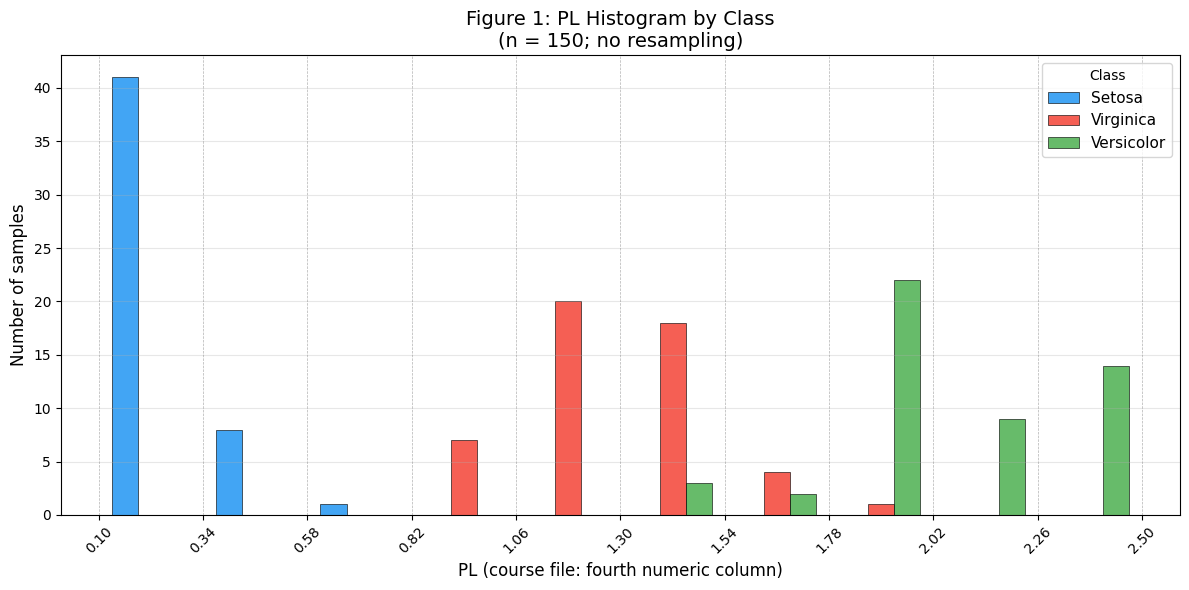

Figure 1 saved to: outputs/assignment1_pl/figure1_pl_histogram_by_class.png


In [20]:
# Figure 1: Class-specific PL histogram
colors = {"Setosa": "#2196F3", "Virginica": "#F44336", "Versicolor": "#4CAF50"}

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = bin_width / 4
x_positions = bin_edges[:-1] + bin_width / 2  # bin centers

for idx, cls in enumerate(class_order):
    counts = count_matrix.loc[cls, bin_labels].values.astype(float)
    offset = (idx - 1) * bar_width
    ax.bar(x_positions + offset, counts, width=bar_width,
           label=cls, color=colors[cls], edgecolor='black', linewidth=0.5, alpha=0.85)

# Mark bin boundaries
for edge in bin_edges:
    ax.axvline(x=edge, color='gray', linestyle='--', linewidth=0.5, alpha=0.6)

ax.set_xlabel('PL (course file: fourth numeric column)', fontsize=12)
ax.set_ylabel('Number of samples', fontsize=12)
ax.set_title('Figure 1: PL Histogram by Class\n(n = 150; no resampling)', fontsize=14)
ax.legend(title='Class', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(bin_edges)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.xticks(rotation=45)

plt.tight_layout()
fig1_path = OUTPUT_DIR / 'figure1_pl_histogram_by_class.png'
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"Figure 1 saved to: {fig1_path}")

### Figure 2: Joint Probability Distribution $P(C, r_i)$

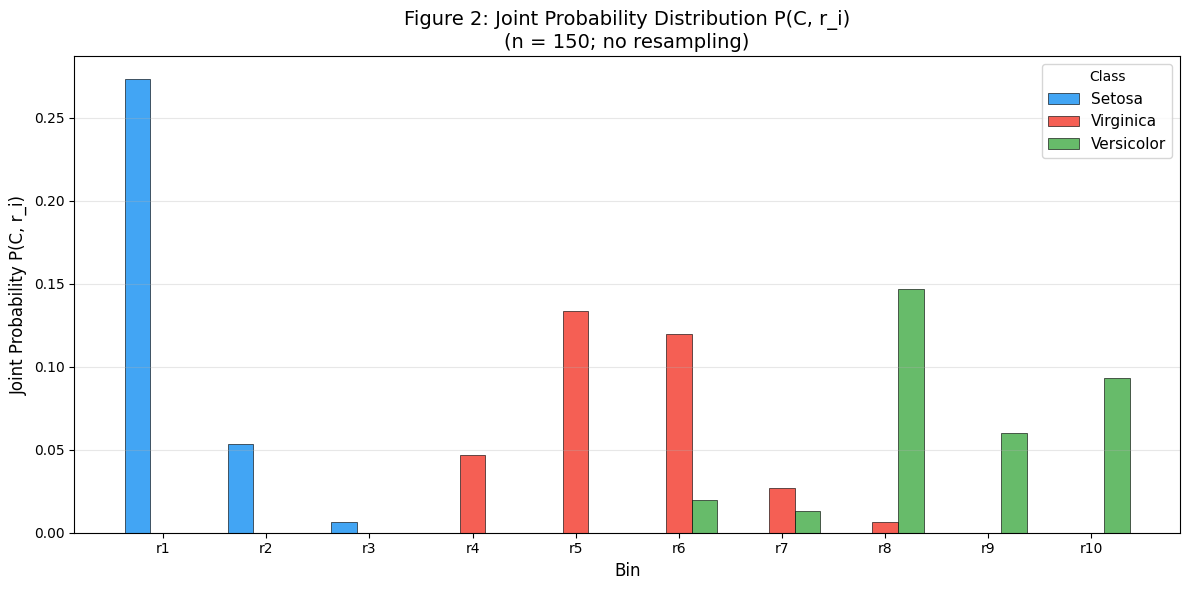

Figure 2 saved to: outputs/assignment1_pl/figure2_joint_probability.png


In [21]:
# Figure 2: Joint probability distribution
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(10)
bar_width_fig2 = 0.25

for idx, cls in enumerate(class_order):
    values = joint_prob.loc[cls, bin_labels].values.astype(float)
    offset = (idx - 1) * bar_width_fig2
    ax.bar(x + offset, values, width=bar_width_fig2,
           label=cls, color=colors[cls], edgecolor='black', linewidth=0.5, alpha=0.85)

ax.set_xlabel('Bin', fontsize=12)
ax.set_ylabel('Joint Probability P(C, r_i)', fontsize=12)
ax.set_title('Figure 2: Joint Probability Distribution P(C, r_i)\n(n = 150; no resampling)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(bin_labels)
ax.legend(title='Class', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig2_path = OUTPUT_DIR / 'figure2_joint_probability.png'
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"Figure 2 saved to: {fig2_path}")

### Figure 3: Posterior Probability Heatmap $P(C | r_i)$

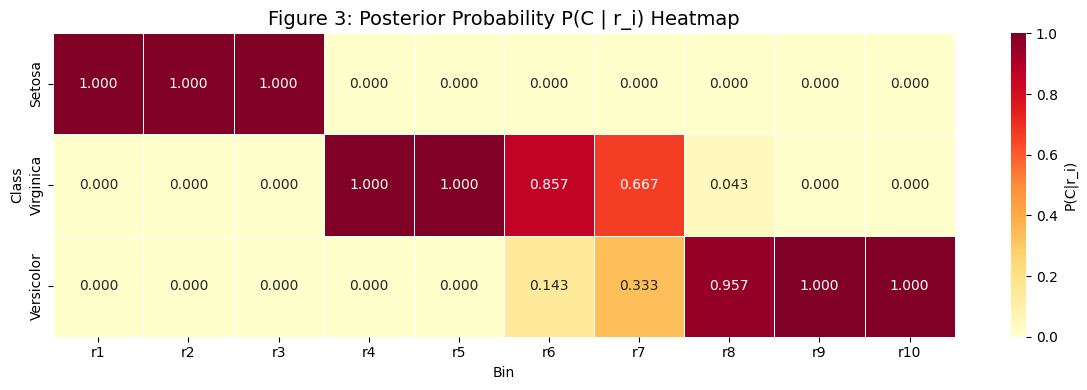

Figure 3 saved to: outputs/assignment1_pl/figure3_posterior_heatmap.png


In [22]:
# Figure 3: Posterior heatmap
fig, ax = plt.subplots(figsize=(12, 4))

heatmap_data = posterior_c_given_r[bin_labels].copy()

# Create annotation matrix with 'N/A' for NaN values
annot_data = heatmap_data.copy().astype(object)
for col in annot_data.columns:
    for row in annot_data.index:
        val = heatmap_data.loc[row, col]
        if pd.isna(val):
            annot_data.loc[row, col] = 'N/A'
        else:
            annot_data.loc[row, col] = f'{val:.3f}'

sns.heatmap(heatmap_data.astype(float), annot=annot_data, fmt='',
            cmap='YlOrRd', ax=ax, linewidths=0.5,
            xticklabels=bin_labels, yticklabels=class_order,
            vmin=0, vmax=1, cbar_kws={'label': 'P(C|r_i)'})

ax.set_title('Figure 3: Posterior Probability P(C | r_i) Heatmap', fontsize=14)
ax.set_xlabel('Bin')
ax.set_ylabel('Class')

plt.tight_layout()
fig3_path = OUTPUT_DIR / 'figure3_posterior_heatmap.png'
plt.savefig(fig3_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"Figure 3 saved to: {fig3_path}")

---
## 8. Interpretation

### Class Separation by PL Bins

Based on the computed distributions:

- **Setosa** occupies the lower PL bins (small petal lengths), forming a well-separated cluster with little to no overlap with the other two classes.
- **Virginica** occupies the higher PL bins (large petal lengths).
- **Versicolor** occupies the middle PL bins, with overlap in the transition bins between Setosa/Versicolor and Versicolor/Virginica.

### Pure vs. Overlapping Bins

- Bins with $P(C|r_i) = 1.0$ for a single class have **pure membership** — all samples in that bin belong to one class.
- Bins where multiple classes have non-zero posterior values show **class overlap** — PL alone cannot perfectly discriminate classes in those regions.

### Distinction Between $P(r_i|C)$ and $P(C|r_i)$

- $P(r_i|C)$ (likelihood): "Given that a sample is class $C$, what is the probability its PL falls in bin $r_i$?" This describes the **distribution of PL within each class**.
- $P(C|r_i)$ (posterior): "Given that a sample's PL falls in bin $r_i$, what is the probability it belongs to class $C$?" This is the **classification question** — which class is most likely for a given measurement?

### Influence of Class Priors

Since all three class priors are equal ($P(C) = 1/3$), the posterior $P(C|r_i)$ is directly proportional to the likelihood $P(r_i|C)$ (via Bayes' theorem). With unequal priors, the posterior would be skewed toward more prevalent classes even for the same likelihood.

### Empty Bins

If any bin has $N(r_i) = 0$ (no observations), then $P(C|r_i)$ is undefined because we cannot condition on an event with zero probability. This is not a failure — it simply means no data exists in that PL range.

### Confirmation

All 150 original samples were used exactly once. No resampling, bootstrapping, or data augmentation was performed. This is a purely empirical distribution of the supplied observations.

---
## 9. Export CSV Result Files

In [23]:
# Export all required CSV files

# 1. Bin definitions
bin_def_df.to_csv(OUTPUT_DIR / 'pl_bin_definitions.csv', index=False)

# 2. Count matrix (all bins)
count_matrix_display.to_csv(OUTPUT_DIR / 'pl_counts_all_bins.csv')

# 3. Joint probabilities (all bins)
joint_prob_display.to_csv(OUTPUT_DIR / 'pl_joint_probabilities_all_bins.csv')

# 4. Priors
priors_df.to_csv(OUTPUT_DIR / 'pl_priors.csv', index=False)

# 5. Bin marginals
marginals_df.to_csv(OUTPUT_DIR / 'pl_bin_marginals.csv', index=False)

# 6. Conditional P(r_i|C) all bins
conditional_r_given_c.to_csv(OUTPUT_DIR / 'pl_conditional_r_given_c_all_bins.csv')

# 7. Posterior P(C|r_i) all bins
posterior_c_given_r.to_csv(OUTPUT_DIR / 'pl_posterior_c_given_r_all_bins.csv')

# 8. Odd bins results (combined table)
odd_results = pd.DataFrame()
for cls in class_order:
    for b in odd_bins:
        odd_results = pd.concat([odd_results, pd.DataFrame([{
            "Bin": b,
            "Class": cls,
            "P(C,r_i)": joint_prob.loc[cls, b],
            "P(r_i|C)": conditional_r_given_c.loc[cls, b],
            "P(C|r_i)": posterior_c_given_r.loc[cls, b],
        }])], ignore_index=True)
odd_results.to_csv(OUTPUT_DIR / 'pl_odd_bins_results.csv', index=False)

# 9. Even bins Bayes verification
bayes_df.to_csv(OUTPUT_DIR / 'pl_even_bins_bayes_verification.csv', index=False)

print("CSV files exported:")
for f in sorted(OUTPUT_DIR.glob('*.csv')):
    print(f"  {f.name} ({f.stat().st_size} bytes)")

CSV files exported:
  pl_bin_definitions.csv (501 bytes)
  pl_bin_marginals.csv (229 bytes)
  pl_conditional_r_given_c_all_bins.csv (202 bytes)
  pl_counts_all_bins.csv (186 bytes)
  pl_even_bins_bayes_verification.csv (1562 bytes)
  pl_joint_probabilities_all_bins.csv (588 bytes)
  pl_odd_bins_results.csv (521 bytes)
  pl_posterior_c_given_r_all_bins.csv (283 bytes)
  pl_priors.csv (110 bytes)


---
## 10. Word Report Generation

In [24]:
def add_table_to_doc(doc, dataframe, title=None, float_fmt='{:.6f}'):
    """Add a pandas DataFrame as a formatted table to the Word document."""
    if title:
        doc.add_paragraph(title, style='Heading 3')

    rows_count, cols_count = dataframe.shape
    has_meaningful_index = not isinstance(dataframe.index, pd.RangeIndex)

    if has_meaningful_index:
        n_cols = cols_count + 1
    else:
        n_cols = cols_count

    table = doc.add_table(rows=rows_count + 1, cols=n_cols)
    table.style = 'Light Grid Accent 1'
    table.alignment = WD_TABLE_ALIGNMENT.CENTER

    # Header row
    col_offset = 0
    if has_meaningful_index:
        table.rows[0].cells[0].text = str(dataframe.index.name or 'Class')
        col_offset = 1
    for j, col_name in enumerate(dataframe.columns):
        table.rows[0].cells[j + col_offset].text = str(col_name)

    # Data rows
    for i in range(rows_count):
        if has_meaningful_index:
            table.rows[i + 1].cells[0].text = str(dataframe.index[i])
        for j in range(cols_count):
            val = dataframe.iloc[i, j]
            if pd.isna(val):
                cell_text = 'N/A'
            elif isinstance(val, float):
                if val == int(val) and abs(val) < 1e6:
                    cell_text = str(int(val))
                else:
                    cell_text = float_fmt.format(val)
            else:
                cell_text = str(val)
            table.rows[i + 1].cells[j + col_offset].text = cell_text

    # Reduce font size for readability
    for row in table.rows:
        for cell in row.cells:
            for paragraph in cell.paragraphs:
                for run in paragraph.runs:
                    run.font.size = Pt(9)

    doc.add_paragraph()  # spacing
    return table


# Create Word document
doc = Document()

# --- Title Page ---
doc.add_heading('AI6124 Assignment 1', level=0)
doc.add_heading('Iris Joint Histogram and Bayesian Probability Analysis', level=1)
doc.add_paragraph(f'Assigned Attribute: Petal Length (PL)')
doc.add_paragraph('Student Name: [Your Name Here]')
doc.add_paragraph('Group Number: [Your Group Number]')
doc.add_paragraph()

# --- Section 1: Objective and Constraints ---
doc.add_heading('1. Objective and Constraints', level=1)
doc.add_paragraph(
    'This report presents the joint histogram and Bayesian probability analysis '
    'of the Petal Length (PL) attribute from the Iris dataset.'
)
constraints = [
    'Exactly 150 samples used (no resampling)',
    'Three course-labelled classes: Setosa, Virginica, Versicolor (50 samples each)',
    '10 equal-width PL bins',
    'No train/test split \u2014 this is a probability distribution exercise',
]
for c in constraints:
    doc.add_paragraph(c, style='List Bullet')

# --- Section 2: Data Convention ---
doc.add_heading('2. Data Convention', level=1)
doc.add_paragraph(
    'PL is the fourth numeric column in the supplied course file. '
    'Column order: SW, SL, PW, PL, Flower Class. '
    'Class codes and names follow the source file exactly: '
    '1.0 = Setosa, 2.0 = Virginica, 3.0 = Versicolor. '
    'These may differ from conventional sklearn Iris dataset labelling.'
)

# --- Section 3: Quantization Method ---
doc.add_heading('3. Quantization Method', level=1)
doc.add_paragraph(
    f'x_min = {x_min}, x_max = {x_max}, '
    f'\u0394 (bin width) = ({x_max} - {x_min}) / 10 = {bin_width:.4f}'
)
doc.add_paragraph(
    'Convention: r_i = [e_{i-1}, e_i) for i = 1,...,9 and r_10 = [e_9, e_10] (inclusive final bin).'
)
add_table_to_doc(doc, bin_def_df.set_index('Bin Number'), 'Bin Definition Table', float_fmt='{:.4f}')

# --- Section 4: Histogram Figure ---
doc.add_heading('4. Class Histogram', level=1)
doc.add_paragraph('Figure 1: PL histogram showing sample counts per bin for each class (n=150, no resampling).')
doc.add_picture(str(fig1_path), width=Inches(6.0))

# --- Section 5: Count/Joint Distribution ---
doc.add_heading('5. Count and Joint Histogram Distribution', level=1)
add_table_to_doc(doc, count_matrix_display, 'Count Matrix N(C, r_i)', float_fmt='{:.0f}')
add_table_to_doc(doc, joint_prob_display, 'Joint Probability Distribution P(C, r_i)', float_fmt='{:.6f}')

# --- Section 6: Priors and Marginals ---
doc.add_heading('6. Class Priors and Bin Marginals', level=1)
add_table_to_doc(doc, priors_df.set_index('Class'), 'Class Prior Probabilities P(C)', float_fmt='{:.6f}')
add_table_to_doc(doc, marginals_df.set_index('Bin'), 'Bin Marginal Probabilities P(r_i)', float_fmt='{:.6f}')

# --- Section 7: Odd-bin Results ---
doc.add_heading('7. Odd-Bin Results (r1, r3, r5, r7, r9)', level=1)
doc.add_paragraph('Required for submission: P(C,r_i), P(r_i|C), and P(C|r_i) for odd bins.')

add_table_to_doc(doc, joint_prob[odd_bins], 'P(C, r_i) \u2014 Odd Bins', float_fmt='{:.6f}')
add_table_to_doc(doc, conditional_r_given_c[odd_bins], 'P(r_i | C) \u2014 Odd Bins', float_fmt='{:.6f}')
add_table_to_doc(doc, posterior_c_given_r[odd_bins], 'P(C | r_i) \u2014 Odd Bins', float_fmt='{:.6f}')

# --- Section 8: Even-bin Bayes Verification ---
doc.add_heading('8. Even-Bin Bayes Verification (r2, r4, r6, r8, r10)', level=1)
doc.add_paragraph(
    'For each even bin with P(r_i) > 0, we verify: '
    'P(C|r_i) = P(r_i|C) \u00d7 P(C) / P(r_i)'
)
add_table_to_doc(doc, bayes_df.set_index(bayes_df.index),
                 'Bayes Formula Verification', float_fmt='{:.6f}')

# --- Section 9: Joint Probability Chart ---
doc.add_heading('9. Joint Probability Chart', level=1)
doc.add_paragraph('Figure 2: Joint probability distribution P(C, r_i) as grouped bar chart.')
doc.add_picture(str(fig2_path), width=Inches(6.0))

doc.add_paragraph('Figure 3: Posterior probability P(C|r_i) heatmap.')
doc.add_picture(str(fig3_path), width=Inches(6.0))

# --- Section 10: Interpretation and Conclusion ---
doc.add_heading('10. Interpretation and Conclusion', level=1)
doc.add_paragraph(
    'The PL attribute shows clear class separation: Setosa occupies the lowest PL bins, '
    'Virginica the highest, and Versicolor the middle range with some overlap at transition bins. '
    'Bins with pure class membership (P(C|r_i) = 1 for a single class) indicate strong '
    'discriminative power of PL in those ranges.'
)
doc.add_paragraph(
    'All probability consistency checks passed: joint probabilities sum to 1, '
    'each P(r_i|C) row sums to 1, each non-empty P(C|r_i) column sums to 1, '
    "and Bayes' formula is verified for all defined even-bin entries."
)
doc.add_paragraph(
    'All 150 original samples were used exactly once with no resampling, '
    'bootstrapping, or data augmentation.'
)

# Add page numbers
from docx.oxml.ns import qn
from docx.oxml import OxmlElement

for section in doc.sections:
    footer = section.footer
    paragraph = footer.paragraphs[0] if footer.paragraphs else footer.add_paragraph()
    paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
    run = paragraph.add_run()
    fldChar1 = OxmlElement('w:fldChar')
    fldChar1.set(qn('w:fldCharType'), 'begin')
    run._r.append(fldChar1)
    instrText = OxmlElement('w:instrText')
    instrText.text = 'PAGE'
    run._r.append(instrText)
    fldChar2 = OxmlElement('w:fldChar')
    fldChar2.set(qn('w:fldCharType'), 'end')
    run._r.append(fldChar2)

# Save the document
report_path = OUTPUT_DIR / 'AI6124_Assignment1_PL_Report.docx'
doc.save(str(report_path))
print(f"Word report saved to: {report_path}")
print(f"File size: {report_path.stat().st_size} bytes")

Word report saved to: outputs/assignment1_pl/AI6124_Assignment1_PL_Report.docx
File size: 386933 bytes


In [25]:
# Verify report content by reopening
verify_doc = Document(str(report_path))

headings_found = [p.text for p in verify_doc.paragraphs if p.style.name.startswith('Heading')]
tables_found = len(verify_doc.tables)
images_found = sum(1 for rel in verify_doc.part.rels.values() if 'image' in rel.reltype)

print("Report Verification:")
print(f"  Headings found: {len(headings_found)}")
for h in headings_found:
    print(f"    - {h}")
print(f"  Tables found: {tables_found}")
print(f"  Images found: {images_found}")

assert len(headings_found) >= 10, "Missing headings in report"
assert tables_found >= 7, "Missing tables in report"
assert images_found >= 3, "Missing images in report"

print("\nReport structure verification: PASS")

Report Verification:
  Headings found: 20
    - Iris Joint Histogram and Bayesian Probability Analysis
    - 1. Objective and Constraints
    - 2. Data Convention
    - 3. Quantization Method
    - Bin Definition Table
    - 4. Class Histogram
    - 5. Count and Joint Histogram Distribution
    - Count Matrix N(C, r_i)
    - Joint Probability Distribution P(C, r_i)
    - 6. Class Priors and Bin Marginals
    - Class Prior Probabilities P(C)
    - Bin Marginal Probabilities P(r_i)
    - 7. Odd-Bin Results (r1, r3, r5, r7, r9)
    - P(C, r_i) — Odd Bins
    - P(r_i | C) — Odd Bins
    - P(C | r_i) — Odd Bins
    - 8. Even-Bin Bayes Verification (r2, r4, r6, r8, r10)
    - Bayes Formula Verification
    - 9. Joint Probability Chart
    - 10. Interpretation and Conclusion
  Tables found: 9
  Images found: 3

Report structure verification: PASS


---
## 11. Download Output Files (Colab)

Run the cell below to download all generated outputs as a zip file.

In [26]:
import shutil
from google.colab import files

# Create zip of all outputs
shutil.make_archive('AI6124_Assignment1_PL_Outputs', 'zip', str(OUTPUT_DIR))
print("Created: AI6124_Assignment1_PL_Outputs.zip")
print("\nContents:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name} ({f.stat().st_size} bytes)")

# Download the zip file
files.download('AI6124_Assignment1_PL_Outputs.zip')

# Also download the Word report directly
files.download(str(report_path))

Created: AI6124_Assignment1_PL_Outputs.zip

Contents:
  AI6124_Assignment1_PL_Report.docx (386933 bytes)
  figure1_pl_histogram_by_class.png (189551 bytes)
  figure2_joint_probability.png (134268 bytes)
  figure3_posterior_heatmap.png (134206 bytes)
  pl_bin_definitions.csv (501 bytes)
  pl_bin_marginals.csv (229 bytes)
  pl_conditional_r_given_c_all_bins.csv (202 bytes)
  pl_counts_all_bins.csv (186 bytes)
  pl_even_bins_bayes_verification.csv (1562 bytes)
  pl_joint_probabilities_all_bins.csv (588 bytes)
  pl_odd_bins_results.csv (521 bytes)
  pl_posterior_c_given_r_all_bins.csv (283 bytes)
  pl_priors.csv (110 bytes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 12. Final Audit

In [27]:
print("=" * 70)
print("FINAL AUDIT CHECKLIST")
print("=" * 70)

checks = []

# 1. Source file exists
checks.append(("Source file exists", DATA_PATH.exists()))

# 2. 150 rows parsed
checks.append(("150 rows parsed", len(df) == 150))

# 3. No rows resampled or dropped
checks.append(("No rows resampled or dropped", len(df) == 150))

# 4. Three classes found
checks.append(("Three classes found", df["class_code"].nunique() == 3))

# 5. 50 samples per class
checks.append(("50 samples per class", all(df["class_code"].value_counts() == 50)))

# 6. Fourth numeric column used as PL
checks.append(("Fourth numeric column used as PL", df.columns[3] == "PL"))

# 7. Exactly 10 bins and 11 edges
checks.append(("Exactly 10 bins and 11 edges", len(bin_labels) == 10 and len(bin_edges) == 11))

# 8. All 150 observations assigned once
checks.append(("All 150 observations assigned once", df["bin_number"].between(1, 10).all() and len(df) == 150))

# 9. Count table grand total is 150
checks.append(("Count table grand total is 150", int(count_matrix_display.loc["Column Total", "Row Total"]) == 150))

# 10. Joint distribution sums to 1
checks.append(("Joint distribution sums to 1", np.isclose(joint_prob[bin_labels].sum().sum(), 1.0, atol=1e-12)))

# 11. Priors sum to 1
checks.append(("Priors sum to 1", np.isclose(priors.sum(), 1.0, atol=1e-12)))

# 12. Each P(r_i|C) row sums to 1
cond_row_sums = conditional_r_given_c.sum(axis=1)
checks.append(("Each P(r_i|C) row sums to 1", all(np.isclose(cond_row_sums, 1.0, atol=1e-12))))

# 13. Each defined P(C|r_i) column sums to 1
post_col_sums = posterior_c_given_r[non_empty_bins].sum(axis=0)
checks.append(("Each defined P(C|r_i) column sums to 1", all(np.isclose(post_col_sums, 1.0, atol=1e-12))))

# 14. All defined even-bin Bayes checks pass
defined_results = bayes_df[bayes_df["Verification"].isin(["PASS", "FAIL"])]
checks.append(("All defined even-bin Bayes checks pass", (defined_results["Verification"] == "PASS").all()))

# 15. Odd-bin result table contains exactly r1, r3, r5, r7, r9
odd_bins_in_results = sorted(odd_results["Bin"].unique())
checks.append(("Odd-bin results contain r1,r3,r5,r7,r9", odd_bins_in_results == sorted(odd_bins)))

# 16. Even-bin verification contains exactly r2, r4, r6, r8, r10
even_bins_in_bayes = sorted(bayes_df["Bin"].unique())
checks.append(("Even-bin verification contains r2,r4,r6,r8,r10", even_bins_in_bayes == sorted(even_bins)))

# 17. All required output files exist and are non-empty
required_files = [
    'figure1_pl_histogram_by_class.png',
    'figure2_joint_probability.png',
    'figure3_posterior_heatmap.png',
    'pl_bin_definitions.csv',
    'pl_counts_all_bins.csv',
    'pl_joint_probabilities_all_bins.csv',
    'pl_priors.csv',
    'pl_bin_marginals.csv',
    'pl_conditional_r_given_c_all_bins.csv',
    'pl_posterior_c_given_r_all_bins.csv',
    'pl_odd_bins_results.csv',
    'pl_even_bins_bayes_verification.csv',
    'AI6124_Assignment1_PL_Report.docx',
]
all_files_ok = all(
    (OUTPUT_DIR / f).exists() and (OUTPUT_DIR / f).stat().st_size > 0
    for f in required_files
)
checks.append(("All required output files exist and non-empty", all_files_ok))

# Print results
all_passed = True
for desc, result in checks:
    status = "PASS" if result else "FAIL"
    if not result:
        all_passed = False
    print(f"  [{status}] {desc}")

print("\n" + "=" * 70)
assert all_passed, "Some audit checks failed!"
print("Assignment 1 PL analysis completed successfully using all 150")
print("original samples with no resampling.")
print("=" * 70)

FINAL AUDIT CHECKLIST
  [PASS] Source file exists
  [PASS] 150 rows parsed
  [PASS] No rows resampled or dropped
  [PASS] Three classes found
  [PASS] 50 samples per class
  [PASS] Fourth numeric column used as PL
  [PASS] Exactly 10 bins and 11 edges
  [PASS] All 150 observations assigned once
  [PASS] Count table grand total is 150
  [PASS] Joint distribution sums to 1
  [PASS] Priors sum to 1
  [PASS] Each P(r_i|C) row sums to 1
  [PASS] Each defined P(C|r_i) column sums to 1
  [PASS] All defined even-bin Bayes checks pass
  [PASS] Odd-bin results contain r1,r3,r5,r7,r9
  [PASS] Even-bin verification contains r2,r4,r6,r8,r10
  [PASS] All required output files exist and non-empty

Assignment 1 PL analysis completed successfully using all 150
original samples with no resampling.
